# A photon and throughput budget for 100,000 cells/second

The instrument goal is to classify $R=10^5$ cells per second. That fixes a hard **time budget** of
$t_{\rm cell}=1/R=10\ \mu\mathrm{s}$ per cell, into which four things must fit: illuminate the cell,
collect its photons, digitize the signal, and run a classifier. This notebook builds the quantitative
budget and answers which stage is the real bottleneck.

The physics thread is the same Poisson photon statistics used to turn emission lines into a
temperature: a cell scatters or fluoresces a finite number of photons $N$, and the signal-to-noise
ratio is $\sqrt N$. The question "can we classify a cell in $10\ \mu\mathrm{s}$?" is really "can we
collect enough photons in $10\ \mu\mathrm{s}$?" -- a statistics problem before it is a compute problem.

Self-contained: NumPy, SymPy, Pandas, Matplotlib, and `math.erfc` from the standard library.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## 1. The time budget

$R=10^5\ \mathrm{s^{-1}}$ gives $t_{\rm cell}=10\ \mu\mathrm{s}$. If the transit waveform is sampled at
$M$ points per cell, the analog-to-digital converter must run at $f_s = M R$.

In [2]:
import math
R = 1e5                                  # cells per second (the goal)
t_cell = 1.0 / R
M = 128                                  # samples digitized per cell transit
f_s = M * R                              # required ADC sample rate
print(f"time per cell      t_cell = {t_cell*1e6:.1f} us")
print(f"samples per cell   M      = {M}")
print(f"required ADC rate  f_s    = {f_s/1e6:.1f} MS/s")
assert abs(t_cell - 1e-5) < 1e-12

time per cell      t_cell = 10.0 us
samples per cell   M      = 128
required ADC rate  f_s    = 12.8 MS/s


## 2. Photon budget and the Poisson limit

A cell emits photons at rate $\Phi$; the optics collect a fraction $\eta$; in the window $t_{\rm cell}$
the detector registers $N=\Phi\,\eta\,t_{\rm cell}$ photons. Photon counting is Poisson, so the shot
noise is $\sqrt N$ and $\mathrm{SNR}=N/\sqrt N=\sqrt N$. Reaching a useful SNR in only $10\ \mu\mathrm{s}$
is the central constraint.

In [3]:
def photons_per_cell(flux, eta, t=t_cell):
    return flux * eta * t
for flux, eta in [(1e10, 0.05), (1e9, 0.10), (1e8, 0.20)]:
    N = photons_per_cell(flux, eta)
    print(f"flux={flux:.0e}/s, eta={eta:.2f}:  N = {N:6.0f} photons/cell,  SNR = sqrt(N) = {np.sqrt(N):5.1f}")
# SNR is set by the collected photon count alone
assert np.isclose(np.sqrt(photons_per_cell(1e9, 0.10)), np.sqrt(1000.0))

flux=1e+10/s, eta=0.05:  N =   5000 photons/cell,  SNR = sqrt(N) =  70.7
flux=1e+09/s, eta=0.10:  N =   1000 photons/cell,  SNR = sqrt(N) =  31.6
flux=1e+08/s, eta=0.20:  N =    200 photons/cell,  SNR = sqrt(N) =  14.1


## 3. How many photons does a classification need? (SymPy + statistics)

Two cell types produce mean photon counts $\mu_0$ and $\mu_1=(1+c)\mu_0$, where $c$ is the contrast.
With Poisson noise $\sigma\approx\sqrt{\bar\mu}$, the separability is the discriminability index
$d'=\dfrac{\mu_1-\mu_0}{\sqrt{\bar\mu}}=c\sqrt{\mu_0}$ (to leading order), and the minimum
classification error of an ideal threshold is $\varepsilon=Q(d'/2)$ with
$Q(x)=\tfrac12\mathrm{erfc}(x/\sqrt2)$. Inverting for the required photon count,
$$\mu_0=\left(\frac{2\,Q^{-1}(\varepsilon)}{c}\right)^2.$$
SymPy confirms the leading-order $d'=c\sqrt{\mu_0}$, and we evaluate the requirement numerically.

In [4]:
mu0, c = sp.symbols('mu0 c', positive=True)
mu1 = (1+c)*mu0
d_prime = sp.simplify((mu1 - mu0)/sp.sqrt((mu0+mu1)/2))
d_prime_lead = sp.series(d_prime, c, 0, 2).removeO()      # leading order in small contrast
print("d' =", d_prime, "  ~", d_prime_lead, "(small c)")
assert sp.simplify(d_prime_lead - c*sp.sqrt(mu0)) == 0

def Q(x):        return 0.5*math.erfc(x/math.sqrt(2))     # Gaussian tail
def Qinv(p):                                              # invert Q by bisection
    lo, hi = 0.0, 12.0
    for _ in range(100):
        mid = 0.5*(lo+hi); (lo, hi) = (mid, hi) if Q(mid) > p else (lo, mid)
    return 0.5*(lo+hi)
def photons_required(contrast, err):
    return (2*Qinv(err)/contrast)**2

rows = []
for contrast in (0.5, 0.2, 0.1):
    for err in (1e-2, 1e-3):
        mu = photons_required(contrast, err)
        rows.append({"contrast c": contrast, "error eps": err, "photons mu0 needed": round(mu),
                     "collect in 10us at rate": f"{mu/t_cell:.1e} /s"})
print(pd.DataFrame(rows).to_string(index=False))

d' = sqrt(2)*c*sqrt(mu0)/sqrt(c + 2)   ~ c*sqrt(mu0) (small c)
 contrast c  error eps  photons mu0 needed collect in 10us at rate
        0.5      0.010                  87              8.7e+06 /s
        0.5      0.001                 153              1.5e+07 /s
        0.2      0.010                 541              5.4e+07 /s
        0.2      0.001                 955              9.5e+07 /s
        0.1      0.010                2165              2.2e+08 /s
        0.1      0.001                3820              3.8e+08 /s


## 4. Compute budget -- and why photons, not FLOPs, are the wall

Per cell the pipeline runs an FFT of the $M$-sample waveform ($\approx 5M\log_2 M$ FLOPs) plus a small
classifier (a $M\times H$ then $H\times2$ matrix-vector product). Multiplied by $R$ cells/s this is the
sustained throughput a CPU or GPU must hold. It comes out in the low GFLOP/s range -- trivial for
modern hardware -- so the binding constraint is collecting enough photons in $10\ \mu\mathrm{s}$, not
arithmetic.

In [5]:
H = 32                                          # hidden units in a tiny classifier
fft_flops = 5*M*np.log2(M)
clf_flops = 2*M*H + 2*H*2                        # two matrix-vector products
per_cell = fft_flops + clf_flops
throughput = per_cell * R
print(f"FFT       : {fft_flops:8.0f} FLOP/cell")
print(f"classifier: {clf_flops:8.0f} FLOP/cell")
print(f"total     : {per_cell:8.0f} FLOP/cell")
print(f"sustained : {throughput/1e9:.3f} GFLOP/s at {R:.0e} cells/s  (a modern CPU exceeds this)")
# ADC data rate for context
print(f"ADC data  : {f_s*12/8/1e6:.1f} MB/s at 12-bit, {M} samples/cell")
assert throughput < 1e11                         # comfortably below CPU/GPU peak

FFT       :     4480 FLOP/cell
classifier:     8320 FLOP/cell
total     :    12800 FLOP/cell
sustained : 1.280 GFLOP/s at 1e+05 cells/s  (a modern CPU exceeds this)
ADC data  : 19.2 MB/s at 12-bit, 128 samples/cell


## 5. Plots

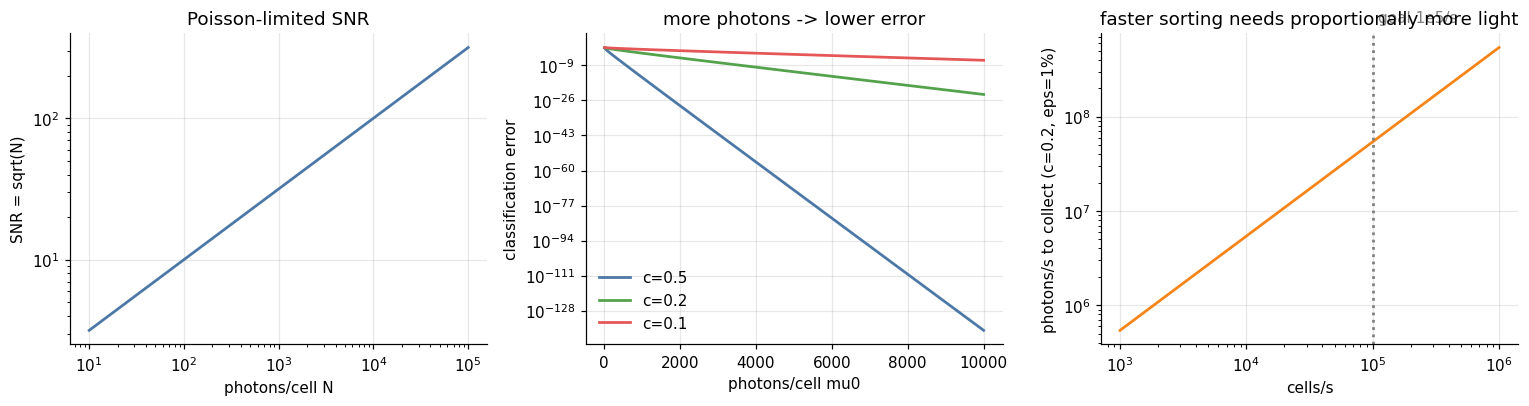

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
# SNR vs photons collected
Ns = np.logspace(1, 5, 100)
ax[0].loglog(Ns, np.sqrt(Ns), color="#4C78A8")
ax[0].set_xlabel("photons/cell N"); ax[0].set_ylabel("SNR = sqrt(N)")
ax[0].set_title("Poisson-limited SNR")
# classification error vs photons for several contrasts
mu = np.logspace(1, 4, 100)
for contrast, cc in [(0.5, "#4C78A8"), (0.2, "#54A24B"), (0.1, "#E45756")]:
    err = [Q(contrast*np.sqrt(m)/2) for m in mu]
    ax[1].semilogy(mu, err, color=cc, label=f"c={contrast}")
ax[1].set_xlabel("photons/cell mu0"); ax[1].set_ylabel("classification error")
ax[1].set_title("more photons -> lower error"); ax[1].legend()
# required collected-photon rate vs throughput goal
Rs = np.logspace(3, 6, 100)
ax[2].loglog(Rs, photons_required(0.2, 1e-2)*Rs, color="#F58518")
ax[2].axvline(1e5, ls=":", color="gray"); ax[2].text(1.1e5, 1e9, "goal 1e5/s", color="gray")
ax[2].set_xlabel("cells/s"); ax[2].set_ylabel("photons/s to collect (c=0.2, eps=1%)")
ax[2].set_title("faster sorting needs proportionally more light")
plt.tight_layout(); plt.show()

## Summary

- The $10^5$ cells/s goal fixes $t_{\rm cell}=10\ \mu\mathrm{s}$; at $M=128$ samples/cell the ADC runs
  at $12.8\ \mathrm{MS/s}$ ($\sim19\ \mathrm{MB/s}$ at 12 bit).
- Photon counting is Poisson, so $\mathrm{SNR}=\sqrt N$; classifying two types at contrast $c$ with
  error $\varepsilon$ needs $\mu_0=(2Q^{-1}(\varepsilon)/c)^2$ photons -- e.g. $c=0.2$, $\varepsilon=1\%$
  needs $\sim540$ photons, i.e. a collected rate of $\sim5\times10^7$ photons/s.
- The compute is only a few GFLOP/s -- far below hardware limits -- so the instrument is
  **photon-limited, not compute-limited**: throughput scales with how much light you collect per cell.

Subject-verb-object: the laser illuminates the cell; the optics collect photons; the ADC digitizes the
transit; the classifier decides; Poisson statistics set the floor. This is the statistical-physics
photon budget behind the sorter's throughput target.